# nuScenes-mini EDA for Camera-Radar Pedestrian Detection

In [21]:
from collections import Counter, defaultdict
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
from IPython.display import Markdown, display
from PIL import Image

from nuscenes.eval.detection.utils import category_to_detection_name
from nuscenes.nuscenes import NuScenes
from nuscenes.utils.data_classes import RadarPointCloud
from nuscenes.utils.geometry_utils import view_points
from nuscenes.utils.splits import create_splits_scenes

plt.style.use("seaborn-v0_8-whitegrid")

PROJECT_ROOT = Path.cwd().resolve()
while PROJECT_ROOT != PROJECT_ROOT.parent and not (PROJECT_ROOT / "pyproject.toml").exists():
    PROJECT_ROOT = PROJECT_ROOT.parent

DATA_ROOT = PROJECT_ROOT / "v1.0-mini"
assert DATA_ROOT.exists(), f"Dataset not found: {DATA_ROOT}" 

nusc = NuScenes(
    version="v1.0-mini",
    dataroot=str(DATA_ROOT),
    verbose=False,
)

def markdown_table(headers, rows):
    lines = [
        "| " + " | ".join(map(str, headers)) + " |",
        "| " + " | ".join(["---"] * len(headers)) + " |",
    ]
    lines.extend("| " + " | ".join(map(str, row)) + " |" for row in rows)
    display(Markdown("\n".join(lines)))

markdown_table(
    ["Item", "Value"],
    [
        ["Dataset root", f"`{DATA_ROOT}`"],
        ["Scenes", len(nusc.scene)],
        ["Annotated keyframes (`sample`)", len(nusc.sample)],
        ["Sensor records (`sample_data`)", len(nusc.sample_data)],
        ["3D box occurrences", len(nusc.sample_annotation)],
        ["Object instances", len(nusc.instance)],
        ["Sensor channels", len(nusc.sensor)],
    ],
)

| Item | Value |
| --- | --- |
| Dataset root | `/Users/williamkuo/Desktop/imec/v1.0-mini` |
| Scenes | 10 |
| Annotated keyframes (`sample`) | 404 |
| Sensor records (`sample_data`) | 31206 |
| 3D box occurrences | 18538 |
| Object instances | 911 |
| Sensor channels | 12 |

## 1. Data model and sensor timing

```text
scene (~20 seconds)
└── sample (annotated keyframe at 2 Hz)
    ├── data[channel] -> sample_data -> sensor file
    │                              ├── calibrated_sensor
    │                              └── ego_pose
    └── anns -> sample_annotation -> instance/category/attributes
```

Important distinctions:

- A `sample` is a synchronized annotated keyframe, not an image.
- `sample_data` is one camera image, radar return, or LiDAR point cloud.
- Camera, radar, and LiDAR operate at approximately 12 Hz, 13 Hz, and 20 Hz, while annotation keyframes are 2 Hz.
- `samples/` contains keyframe sensor data; `sweeps/` contains intermediate measurements.
- `sample_annotation.translation` is in the **global map frame**. A value such as `[373, 1130, ...]` is not distance from the car.
- Projection requires sensor → ego at sensor time → global → ego at camera time → camera → image.

Sources: [nuScenes schema](https://github.com/nutonomy/nuscenes-devkit/blob/master/docs/schema_nuscenes.md), [nuScenes paper](https://openaccess.thecvf.com/content_CVPR_2020/papers/Caesar_nuScenes_A_Multimodal_Dataset_for_Autonomous_Driving_CVPR_2020_paper.pdf).

In [22]:
official_splits = create_splits_scenes()
scene_name_by_token = {scene["token"]: scene["name"] for scene in nusc.scene}
scene_to_split = {
    scene_name: split_name
    for split_name in ("mini_train", "mini_val")
    for scene_name in official_splits[split_name]
}

sensor_rows = [
    [sensor["channel"], sensor["modality"]]
    for sensor in sorted(nusc.sensor, key=lambda item: (item["modality"], item["channel"]))
]
display(Markdown("### Sensor channels"))
markdown_table(["Channel", "Modality"], sensor_rows)

scene_rows = [
    [
        scene["name"],
        scene_to_split[scene["name"]],
        scene["nbr_samples"],
        scene["description"],
    ]
    for scene in nusc.scene
]
display(Markdown("### Mini scenes"))
markdown_table(["Scene", "Split", "Samples", "Description"], scene_rows)

### Sensor channels

| Channel | Modality |
| --- | --- |
| CAM_BACK | camera |
| CAM_BACK_LEFT | camera |
| CAM_BACK_RIGHT | camera |
| CAM_FRONT | camera |
| CAM_FRONT_LEFT | camera |
| CAM_FRONT_RIGHT | camera |
| LIDAR_TOP | lidar |
| RADAR_BACK_LEFT | radar |
| RADAR_BACK_RIGHT | radar |
| RADAR_FRONT | radar |
| RADAR_FRONT_LEFT | radar |
| RADAR_FRONT_RIGHT | radar |

### Mini scenes

| Scene | Split | Samples | Description |
| --- | --- | --- | --- |
| scene-0061 | mini_train | 39 | Parked truck, construction, intersection, turn left, following a van |
| scene-0103 | mini_val | 40 | Many peds right, wait for turning car, long bike rack left, cyclist |
| scene-0553 | mini_train | 41 | Wait at intersection, bicycle, large truck, peds crossing crosswalk, ped with stroller |
| scene-0655 | mini_train | 41 | Parking lot, parked cars, jaywalker, bendy bus, gardening vehicles |
| scene-0757 | mini_train | 41 | Arrive at busy intersection, bus, wait at intersection, bicycle, peds |
| scene-0796 | mini_train | 40 | Scooter, peds on sidewalk, bus, cars, truck, fake construction worker, bicycle, cross intersection, car overtaking us |
| scene-0916 | mini_val | 41 | Parking lot, bicycle rack, parked bicycles, bus, many peds, parked scooters, parked motorcycle |
| scene-1077 | mini_train | 41 | Night, big street, bus stop, high speed, construction vehicle |
| scene-1094 | mini_train | 40 | Night, after rain, many peds, PMD, ped with bag, jaywalker, truck, scooter |
| scene-1100 | mini_train | 40 | Night, peds in sidewalk, peds cross crosswalk, scooter, PMD, difficult lighting |

## 2. Task definition and evaluation boundary

This project uses a deliberately constrained task:

- **Input:** `CAM_FRONT` and front radar measurements.
- **Target:** official nuScenes detection class `pedestrian`.
- **Region of interest:** objects visible in `CAM_FRONT`, within the official pedestrian range of 40 m.
- **Split:** official scene-level `mini_train` / `mini_val`; frames are never randomly split.
- **Output:** front-view 2D pedestrian boxes for a lightweight proof-of-concept.

The general nuScenes taxonomy contains 23 classes, while the detection benchmark maps them into 10 detection classes. In particular, `human.pedestrian.personal_mobility`, `stroller`, and `wheelchair` are ignored by the official detection mapping. Therefore, `name.startswith('human.pedestrian')` is not a correct target definition.

Because this project predicts front-view 2D boxes rather than full 360° 3D boxes, results will use 2D AP/precision/recall and **will not be presented as official nuScenes NDS**. The official class mapping and range filter are still used to make the target definition principled.

Source: [nuScenes detection protocol](https://github.com/nutonomy/nuscenes-devkit/blob/master/python-sdk/nuscenes/eval/detection/README.md).

| Split | Scenes | Samples |
| --- | --- | --- |
| mini_train | 8 | 323 |
| mini_val | 2 | 81 |

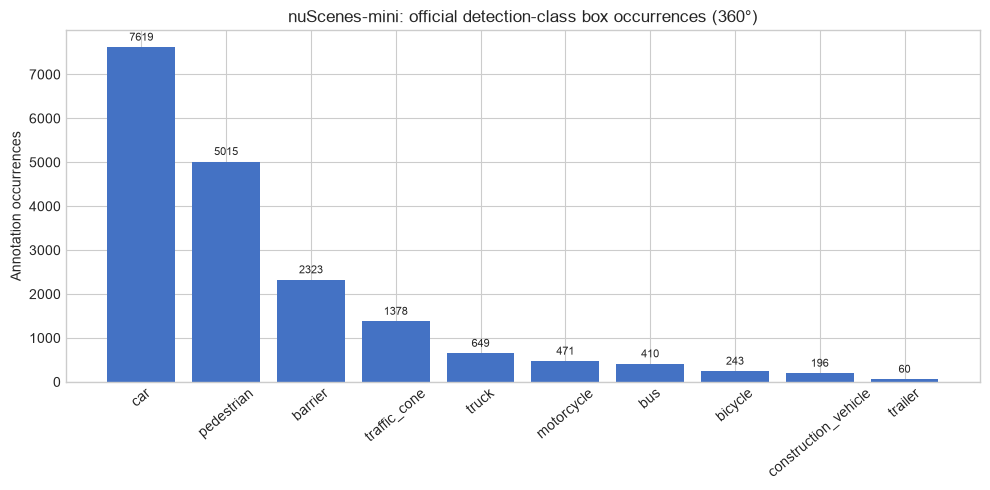

In [23]:
samples_per_split = Counter()
detection_class_counts = Counter()

for sample in nusc.sample:
    scene_name = scene_name_by_token[sample["scene_token"]]
    samples_per_split[scene_to_split[scene_name]] += 1

    for annotation_token in sample["anns"]:
        annotation = nusc.get("sample_annotation", annotation_token)
        detection_name = category_to_detection_name(annotation["category_name"])
        if detection_name is not None:
            detection_class_counts[detection_name] += 1

markdown_table(
    ["Split", "Scenes", "Samples"],
    [
        ["mini_train", len(official_splits["mini_train"]), samples_per_split["mini_train"]],
        ["mini_val", len(official_splits["mini_val"]), samples_per_split["mini_val"]],
    ],
)

ordered_classes = detection_class_counts.most_common()
names = [name for name, _ in ordered_classes]
counts = [count for _, count in ordered_classes]

fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.bar(names, counts, color="#4472C4")
ax.set_title("nuScenes-mini: official detection-class box occurrences (360°)")
ax.set_ylabel("Annotation occurrences")
ax.tick_params(axis="x", rotation=40)
ax.bar_label(bars, padding=3, fontsize=8)
fig.tight_layout()
plt.show()

In [24]:
# calculate the distance from the ego vehicle to the annotation
def distance_from_ego(sample, ann):
    sd = nusc.get("sample_data", sample["data"]["LIDAR_TOP"])
    ego = nusc.get("ego_pose", sd["ego_pose_token"])

    return np.linalg.norm(
        np.array(ann["translation"][:2]) -
        np.array(ego["translation"][:2])
    )

In [25]:
pedestrian_records = []
frames_by_split = Counter()
frames_with_ped = Counter()

for sample in nusc.sample:
    scene = scene_name_by_token[sample["scene_token"]]
    split = scene_to_split[scene]
    frames_by_split[split] += 1

    _, boxes, _ = nusc.get_sample_data(sample["data"]["CAM_FRONT"])

    ped_boxes = [
        box for box in boxes
        if category_to_detection_name(box.name) == "pedestrian"
    ]

    if ped_boxes:
        frames_with_ped[split] += 1

    for box in ped_boxes:
        ann = nusc.get("sample_annotation", box.token)
        distance = distance_from_ego(sample, ann)

        pedestrian_records.append({
            "split": split,
            "scene": scene,
            "instance": ann["instance_token"],
            "distance_m": distance,
            "within_40m": distance <= 40,
            "radar_pts": ann["num_radar_pts"],
        })

In [5]:
summary_by_split = {}

for split_name in ("mini_train", "mini_val"):
    records = [record for record in pedestrian_records if record["split"] == split_name]
    within_40m = [record for record in records if record["within_40m"]]
    no_radar = [record for record in within_40m if record["num_radar_pts"] == 0]
    official_style = [record for record in within_40m if not record["both_sensors_zero"]]

    summary_by_split[split_name] = {
        "scenes": len(official_splits[split_name]),
        "frames": frames_by_split[split_name],
        "frames_with_ped": frames_with_pedestrian[split_name],
        "boxes": len(records),
        "instances": len({record["instance_token"] for record in records}),
        "within_40m": len(within_40m),
        "no_radar": len(no_radar),
        "no_radar_pct": 100.0 * len(no_radar) / len(within_40m),
        "official_style_targets": len(official_style),
        "median_distance": float(np.median([record["distance_m"] for record in records])),
    }

markdown_table(
    [
        "Split", "Scenes", "Frames", "Frames with ped",
        "Front ped boxes", "Unique instances", "≤40 m",
        "No radar ≤40 m", "Official-style targets", "Median distance",
    ],
    [
        [
            split_name,
            values["scenes"],
            values["frames"],
            f'{values["frames_with_ped"]} ({100 * values["frames_with_ped"] / values["frames"]:.1f}%)',
            values["boxes"],
            values["instances"],
            values["within_40m"],
            f'{values["no_radar"]} ({values["no_radar_pct"]:.1f}%)',
            values["official_style_targets"],
            f'{values["median_distance"]:.1f} m',
        ]
        for split_name, values in summary_by_split.items()
    ],
)

| Split | Scenes | Frames | Frames with ped | Front ped boxes | Unique instances | ≤40 m | No radar ≤40 m | Official-style targets | Median distance |
| --- | --- | --- | --- | --- | --- | --- | --- | --- | --- |
| mini_train | 8 | 323 | 168 (52.0%) | 835 | 80 | 510 | 429 (84.1%) | 463 | 33.7 m |
| mini_val | 2 | 81 | 50 (61.7%) | 299 | 43 | 248 | 200 (80.6%) | 233 | 25.5 m |

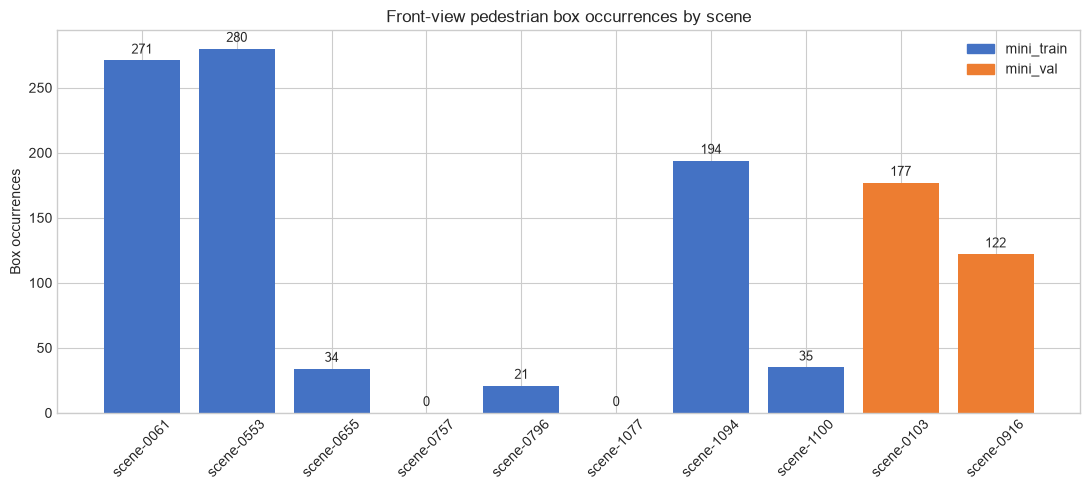

In [6]:
ordered_scenes = sorted(
    pedestrians_by_scene,
    key=lambda name: (scene_to_split[name] == "mini_val", name),
)
scene_counts = [pedestrians_by_scene[name] for name in ordered_scenes]
scene_colors = [
    "#4472C4" if scene_to_split[name] == "mini_train" else "#ED7D31"
    for name in ordered_scenes
]

fig, ax = plt.subplots(figsize=(11, 5))
bars = ax.bar(ordered_scenes, scene_counts, color=scene_colors)
ax.set_title("Front-view pedestrian box occurrences by scene")
ax.set_ylabel("Box occurrences")
ax.tick_params(axis="x", rotation=45)
ax.bar_label(bars, padding=3, fontsize=9)
ax.legend(
    handles=[
        plt.Rectangle((0, 0), 1, 1, color="#4472C4", label="mini_train"),
        plt.Rectangle((0, 0), 1, 1, color="#ED7D31", label="mini_val"),
    ]
)
fig.tight_layout()
plt.show()

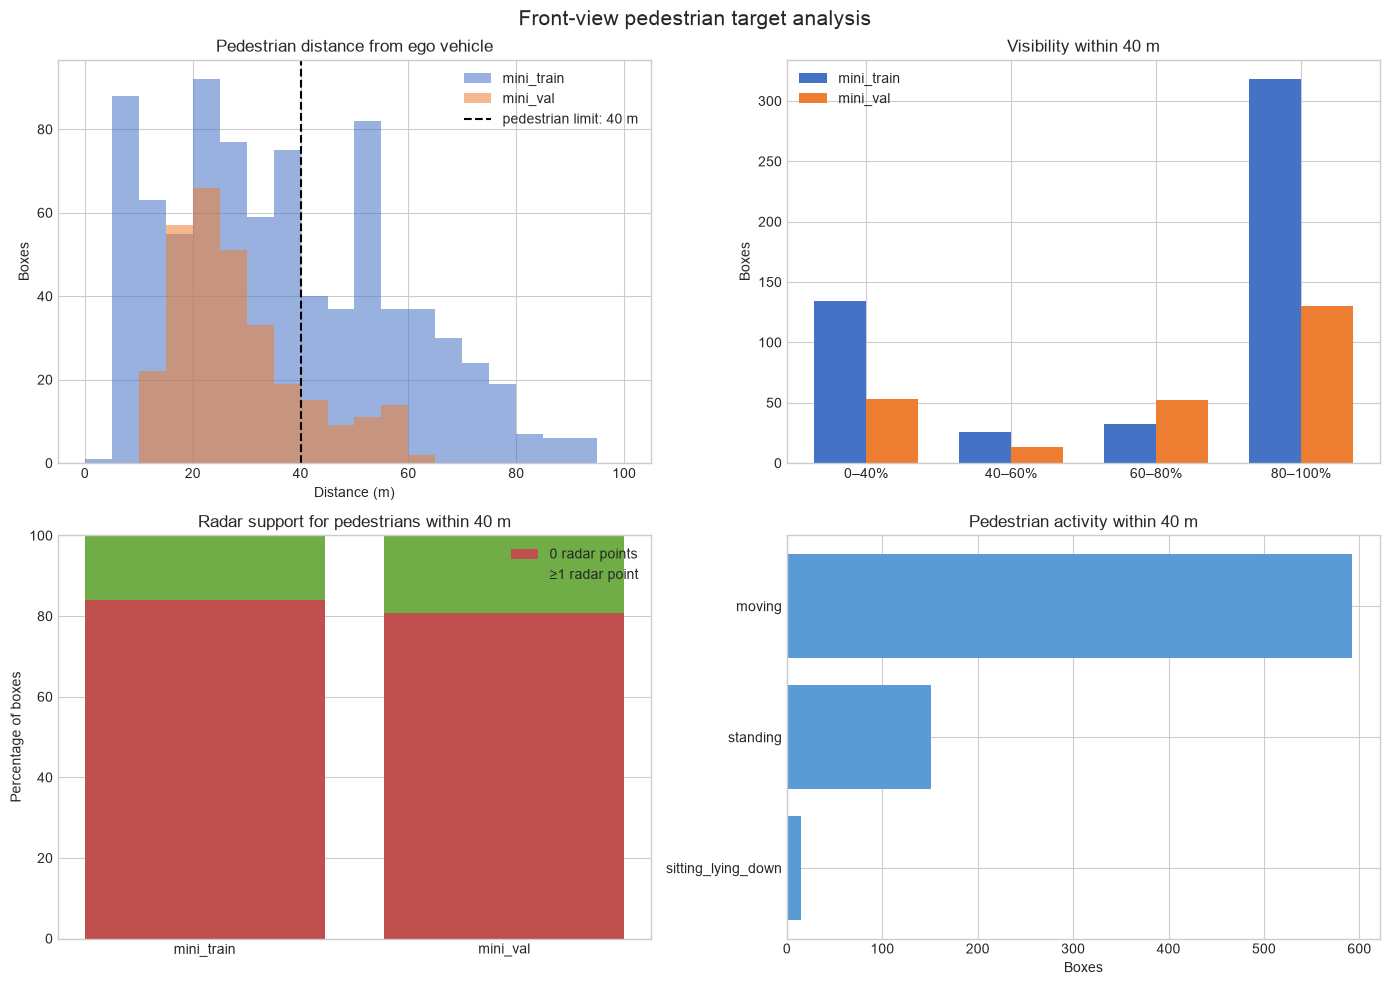

In [7]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Distance distribution.
for split_name, color in (("mini_train", "#4472C4"), ("mini_val", "#ED7D31")):
    distances = [
        record["distance_m"]
        for record in pedestrian_records
        if record["split"] == split_name
    ]
    axes[0, 0].hist(distances, bins=np.arange(0, 101, 5), alpha=0.55, label=split_name, color=color)
axes[0, 0].axvline(40, color="black", linestyle="--", label="pedestrian limit: 40 m")
axes[0, 0].set(title="Pedestrian distance from ego vehicle", xlabel="Distance (m)", ylabel="Boxes")
axes[0, 0].legend()

# Visibility distribution.
visibility_order = [
    "visibility of whole object is between 0 and 40%",
    "visibility of whole object is between 40 and 60%",
    "visibility of whole object is between 60 and 80%",
    "visibility of whole object is between 80 and 100%",
]
visibility_labels = ["0–40%", "40–60%", "60–80%", "80–100%"]
x = np.arange(len(visibility_order))
width = 0.36
for offset, split_name, color in ((-width / 2, "mini_train", "#4472C4"), (width / 2, "mini_val", "#ED7D31")):
    counts = Counter(
        record["visibility"]
        for record in pedestrian_records
        if record["split"] == split_name and record["within_40m"]
    )
    axes[0, 1].bar(x + offset, [counts[level] for level in visibility_order], width, label=split_name, color=color)
axes[0, 1].set(title="Visibility within 40 m", ylabel="Boxes", xticks=x, xticklabels=visibility_labels)
axes[0, 1].legend()

# Radar support.
splits = ["mini_train", "mini_val"]
no_radar_pct = [summary_by_split[name]["no_radar_pct"] for name in splits]
radar_pct = [100 - value for value in no_radar_pct]
axes[1, 0].bar(splits, no_radar_pct, label="0 radar points", color="#C0504D")
axes[1, 0].bar(splits, radar_pct, bottom=no_radar_pct, label="≥1 radar point", color="#70AD47")
axes[1, 0].set(title="Radar support for pedestrians within 40 m", ylabel="Percentage of boxes", ylim=(0, 100))
axes[1, 0].legend()

# Pedestrian activity attributes.
attribute_counts = Counter()
for record in pedestrian_records:
    if record["within_40m"]:
        attribute_counts.update(record["attributes"])
attribute_items = attribute_counts.most_common()
axes[1, 1].barh(
    [name.replace("pedestrian.", "") for name, _ in reversed(attribute_items)],
    [count for _, count in reversed(attribute_items)],
    color="#5B9BD5",
)
axes[1, 1].set(title="Pedestrian activity within 40 m", xlabel="Boxes")

fig.suptitle("Front-view pedestrian target analysis", fontsize=15)
fig.tight_layout()
plt.show()

In [ ]:
train = summary_by_split["mini_train"]
val = summary_by_split["mini_val"]

display(Markdown(f"""
## 3. Findings that affect model design

### 1. The effective dataset is much smaller than the raw annotation count

The {detection_class_counts['pedestrian']:,} pedestrian annotations in mini cover 360° and repeated time steps. For the chosen front-view task there are {train['boxes']:,} train and {val['boxes']:,} validation box occurrences, representing only {train['instances']} and {val['instances']} unique instances. After applying the 40 m range and removing boxes with neither LiDAR nor radar support, only **{train['official_style_targets']:,} train** and **{val['official_style_targets']:,} validation** target occurrences remain. A large model trained from scratch would likely overfit; a pretrained, partly frozen camera encoder is more appropriate.

### 2. Scene imbalance makes random frame splitting invalid

A few scenes contain most front-view pedestrian boxes, while some scenes contain none. Adjacent keyframes also repeat the same object instances. Randomly splitting frames would leak near-identical images and people across train and validation. The official scene split is mandatory.

### 3. Radar is missing for most pedestrian boxes

Within 40 m, {train['no_radar_pct']:.1f}% of train and {val['no_radar_pct']:.1f}% of validation pedestrian boxes have `num_radar_pts == 0`. This field sums points across all radar sensors and applies no invalid-point filtering, so `RADAR_FRONT` alone is at least as sparse. Fusion must therefore tolerate missing radar evidence rather than assuming every target has a radar return.

### 4. Train and validation are not identically distributed

The median front-view pedestrian distance is {train['median_distance']:.1f} m in train and {val['median_distance']:.1f} m in validation. Mini contains only two validation scenes, both rich in pedestrians. Metrics will have high variance and must be presented as proof-of-concept results rather than large-scale generalization.

### Modeling consequences

- Use a pretrained lightweight camera backbone.
- Aggregate several radar sweeps and include time lag as a feature.
- Use gated fusion or cross-attention with an explicit radar-validity/occupancy channel.
- Include a camera-only baseline and a single-sweep vs multi-sweep ablation.
- Report performance by distance and visibility, not only one aggregate AP value.
"""))


## 3. Findings that affect model design

### 1. The effective dataset is much smaller than the raw annotation count

The 5,015 pedestrian annotations in mini cover 360° and repeated time steps. For the chosen front-view task there are 835 train and 299 validation box occurrences, representing only 80 and 43 unique instances. After applying the 40 m range and removing boxes with neither LiDAR nor radar support, only **463 train** and **233 validation** target occurrences remain. A large model trained from scratch would likely overfit; a pretrained, partly frozen camera encoder is more appropriate.

### 2. Scene imbalance makes random frame splitting invalid

A few scenes contain most front-view pedestrian boxes, while some scenes contain none. Adjacent keyframes also repeat the same object instances. Randomly splitting frames would leak near-identical images and people across train and validation. The official scene split is mandatory.

### 3. Radar is missing for most pedestrian boxes

Within 40 m, 84.1% of train and 80.6% of validation pedestrian boxes have `num_radar_pts == 0`. This field sums points across all radar sensors and applies no invalid-point filtering, so `RADAR_FRONT` alone is at least as sparse. Fusion must therefore tolerate missing radar evidence rather than assuming every target has a radar return.

### 4. Train and validation are not identically distributed

The median front-view pedestrian distance is 33.7 m in train and 25.5 m in validation. Mini contains only two validation scenes, both rich in pedestrians. Metrics will have high variance and must be presented as proof-of-concept results rather than large-scale generalization.

### Modeling consequences

- Use a pretrained lightweight camera backbone.
- Aggregate several radar sweeps and include time lag as a feature.
- Use gated fusion or cross-attention with an explicit radar-validity/occupancy channel.
- Include a camera-only baseline and a single-sweep vs multi-sweep ablation.
- Report performance by distance and visibility, not only one aggregate AP value.


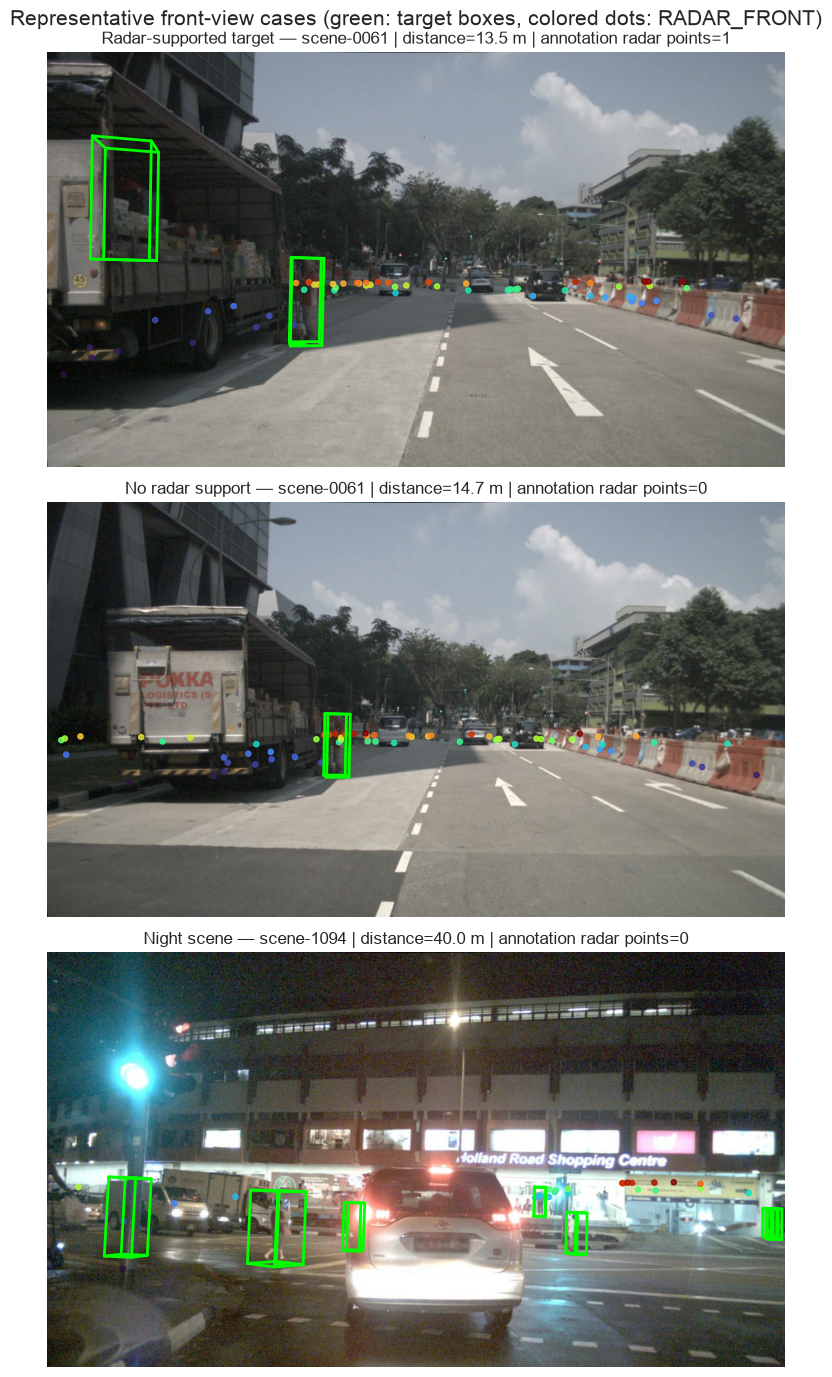

In [9]:
def draw_target_boxes(ax, sample):
    camera_token = sample["data"]["CAM_FRONT"]
    _, boxes, camera_intrinsic = nusc.get_sample_data(camera_token)
    for box in boxes:
        if category_to_detection_name(box.name) != "pedestrian":
            continue
        annotation = nusc.get("sample_annotation", box.token)
        if annotation_distance_from_ego(sample, annotation) > 40.0:
            continue
        if annotation["num_lidar_pts"] + annotation["num_radar_pts"] == 0:
            continue
        box.render(
            ax,
            view=np.asarray(camera_intrinsic),
            normalize=True,
            colors=("lime", "lime", "lime"),
        )

def render_camera_radar_sample(ax, record, title):
    sample = nusc.get("sample", record["sample_token"])
    camera_token = sample["data"]["CAM_FRONT"]
    radar_token = sample["data"]["RADAR_FRONT"]
    points, depth, image = nusc.explorer.map_pointcloud_to_image(radar_token, camera_token)

    ax.imshow(image)
    ax.scatter(points[0], points[1], c=depth, cmap="turbo", s=14, alpha=0.85)
    draw_target_boxes(ax, sample)
    ax.set_title(title)
    ax.axis("off")

supported = next(
    record for record in pedestrian_records
    if record["split"] == "mini_train" and record["within_40m"] and record["num_radar_pts"] > 0
)
unsupported = next(
    record for record in pedestrian_records
    if record["split"] == "mini_train" and record["within_40m"] and record["num_radar_pts"] == 0
)
night = next(
    record for record in pedestrian_records
    if record["scene"] in {"scene-1094", "scene-1100"} and record["within_40m"]
)

cases = [
    (supported, f'Radar-supported target — {supported["scene"]}'),
    (unsupported, f'No radar support — {unsupported["scene"]}'),
    (night, f'Night scene — {night["scene"]}'),
]

fig, axes = plt.subplots(3, 1, figsize=(15, 14))
for ax, (record, title) in zip(axes, cases):
    render_camera_radar_sample(
        ax,
        record,
        f'{title} | distance={record["distance_m"]:.1f} m | annotation radar points={record["num_radar_pts"]}',
    )
fig.suptitle("Representative front-view cases (green: target boxes, colored dots: RADAR_FRONT)", fontsize=15)
fig.tight_layout()
plt.show()

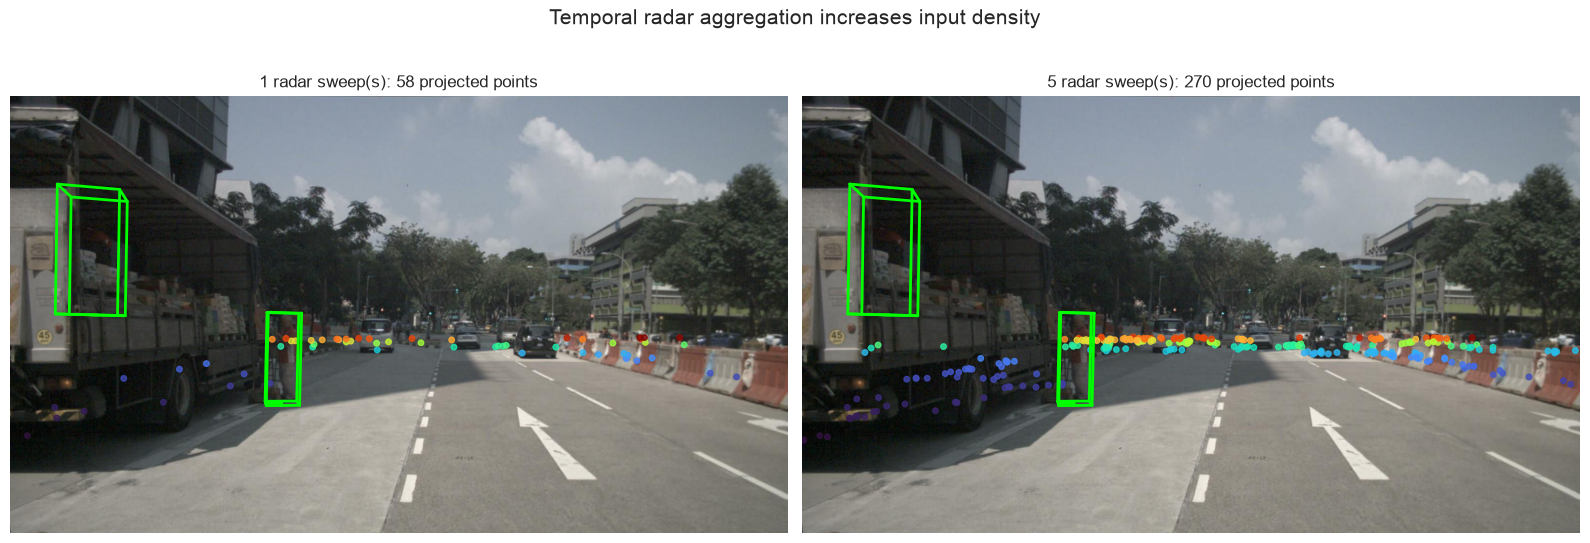

In [ ]:
def project_front_radar_multisweep(sample, nsweeps):
    # Retrieve data from RADAR_FRONT, not just for the current sweep, but aggregate from previous sweeps as well
    radar, time_lags = RadarPointCloud.from_file_multisweep(
        nusc=nusc,
        sample_rec=sample,
        chan="RADAR_FRONT",
        ref_chan="CAM_FRONT",
        nsweeps=nsweeps,
        min_distance=1.0,
    )

    camera_record = nusc.get("sample_data", sample["data"]["CAM_FRONT"])
    calibration = nusc.get("calibrated_sensor", camera_record["calibrated_sensor_token"])
    camera_intrinsic = np.asarray(calibration["camera_intrinsic"], dtype=float)
    pixels = view_points(radar.points[:3], camera_intrinsic, normalize=True)
    depth = radar.points[2]

    # Filter out unwanted points
    mask = (
        (depth > 1.0)
        & (pixels[0] >= 0)
        & (pixels[0] < camera_record["width"])
        & (pixels[1] >= 0)
        & (pixels[1] < camera_record["height"])
    )

    image_path = Path(nusc.dataroot) / camera_record["filename"]
    return Image.open(image_path), pixels[:, mask], depth[mask], time_lags[:, mask]

comparison_sample = nusc.get("sample", supported["sample_token"])
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Compare radar sweeps with different sampling counts
for ax, nsweeps in zip(axes, (1, 5)):
    image, pixels, depth, time_lags = project_front_radar_multisweep(comparison_sample, nsweeps)
    ax.imshow(image)
    ax.scatter(pixels[0], pixels[1], c=depth, cmap="turbo", s=16, alpha=0.8)
    draw_target_boxes(ax, comparison_sample)
    ax.set_title(f"{nsweeps} radar sweep(s): {pixels.shape[1]} projected points")
    ax.axis("off")

fig.suptitle("Temporal radar aggregation increases input density", fontsize=15)
fig.tight_layout()
plt.show()

## 4. Training plan justified by the EDA

### Dataset protocol

- Train on the 8 official `mini_train` scenes and evaluate once on the 2 `mini_val` scenes.
- Use only boxes mapped by `category_to_detection_name(...) == 'pedestrian'`.
- Require visibility in `CAM_FRONT`, distance ≤40 m, and at least one LiDAR or radar point to follow the official GT filtering principle.
- Do not use scene descriptions as model inputs; they are inspected only for EDA.

### Proposed preprocessing

- Resize `CAM_FRONT` from 1600×900 to approximately 640×360 and scale projected boxes/points consistently.
- Aggregate 5 past `RADAR_FRONT` sweeps into the current camera frame.
- Rasterize radar into sparse channels such as occupancy, depth, RCS, compensated speed magnitude, and time lag.
- Keep a radar-validity channel so the network can distinguish missing measurements from zero-valued measurements.

### Proposed model

- Pretrained ResNet-18 or MobileNetV3 camera encoder, initially partly frozen.
- Small CNN radar encoder.
- Gated or cross-attention fusion, followed by a lightweight 2D detection head.
- The model must still produce a valid prediction when the radar tensor is empty.

### Required ablations

1. Camera only.
2. Camera + one radar sweep.
3. Camera + five radar sweeps.
4. Camera + five sweeps with gated/cross-attention fusion.

### Evaluation

- 2D AP at IoU 0.50, precision, recall, and F1.
- Report near (0–20 m) and far (20–40 m) performance.
- Report performance by visibility bin and show success/failure examples.
- Repeat training with several seeds if compute permits; mini validation contains only two scenes.
- Do not label these custom front-view metrics as official nuScenes mAP or NDS.

## 5. Dataset understanding cheat sheet

### Camera

- Six rectified 1600×900 cameras with intrinsic and extrinsic calibration.
- Appearance is strong for pedestrians but sensitive to darkness, rain, occlusion, and small distant objects.

### Radar

- Five radars with sparse point returns.
- Each point has 18 fields including XYZ, RCS, raw velocity, ego-motion-compensated velocity, dynamic state, ambiguity state, quality flags, and uncertainty fields.
- Compensated velocity is preferable to raw velocity, but directional velocity features require care when changing coordinate frames.
- Multi-sweep aggregation adds density and time context, but may create trails for moving objects; time lag should be preserved.

### LiDAR

- One 32-beam LiDAR. It is used here for dataset understanding and official-style GT filtering, not as a model input.

### Annotation

- 3D boxes are stored in global coordinates and linked across time by `instance_token`, `prev`, and `next`.
- `num_radar_pts` is summed over all radars without invalid-point filtering.
- Visibility is measured across the panoramic six-camera view, not only `CAM_FRONT`.
- Box occurrences across keyframes are correlated; they are not independent examples.

### Key limitations of this project

- Mini contains only 10 scenes, 8 for training and 2 for validation.
- Validation is pedestrian-rich and closer-range relative to training.
- Radar support for pedestrians is extremely sparse.
- Results demonstrate feasibility and design understanding, not benchmark-level generalization.

References: [dataset schema](https://github.com/nutonomy/nuscenes-devkit/blob/master/docs/schema_nuscenes.md), [radar fields](https://github.com/nutonomy/nuscenes-devkit/blob/master/python-sdk/nuscenes/utils/data_classes.py), [annotation instructions](https://github.com/nutonomy/nuscenes-devkit/blob/master/docs/instructions_nuscenes.md), [detection protocol](https://github.com/nutonomy/nuscenes-devkit/blob/master/python-sdk/nuscenes/eval/detection/README.md).

## 6. Conclusion and next implementation milestone

The EDA supports a lightweight, missing-radar-aware front-view fusion project. The next milestone is not a large model: it is a reusable PyTorch `Dataset` that returns one camera tensor, one radar tensor, and filtered 2D pedestrian targets while reproducing the exact split and filtering decisions documented above.

Before training, manually verify at least ten samples across day, night, near/far, visible/occluded, radar-supported, and radar-missing cases.